# 04_transfer_learning_densenet121.ipynb

Denne notebooken trener en pretrained DenseNet121 for multi-label klassifisering
av CheXpert-bildene. Modellen brukes som transfer learning-eksperiment og
sammenlignes med baseline-CNN fra notebook 3.

Plan:
1. Last inn data og pipeline
2. Bygg DenseNet121 med pretrained ImageNet-vekter
3. Tren klassifikasjonshodet med frozen backbone
4. Fine-tune øvre lag i backbone
5. Evaluer og lagre resultater
6. Sammenlign med baseline


In [10]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from google.colab import drive, userdata

In [11]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

mixed_precision.set_global_policy("mixed_float16")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

print("TensorFlow version:", tf.__version__)
print("GPU available:", gpus)
print("Mixed precision policy:", mixed_precision.global_policy())

GPU memory growth enabled
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [12]:
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/DAT255_CheXpert_Project")
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("PROCESSED_DIR exists:", PROCESSED_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/MyDrive/DAT255_CheXpert_Project
PROCESSED_DIR exists: True


In [13]:
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

import kagglehub
DATASET_ROOT = Path(kagglehub.dataset_download("ashery/chexpert"))

print("DATASET_ROOT:", DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

Using Colab cache for faster access to the 'chexpert' dataset.
DATASET_ROOT: /kaggle/input/chexpert
Exists: True


In [14]:
LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion"
]

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
HEAD_EPOCHS = 5
FINETUNE_EPOCHS = 5
AUTOTUNE = tf.data.AUTOTUNE

TRAIN_CSV = PROCESSED_DIR / "train_clean_competition_5_U-Ones.csv"
VALID_CSV = PROCESSED_DIR / "valid_clean_competition_5_U-Ones.csv"
PATH_COL = "Path"
NUM_LABELS = len(LABELS)

print("Labels:", LABELS)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Labels: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']
Image size: (224, 224)
Batch size: 32


In [15]:
train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)

train_df.head()

Train shape: (191027, 22)
Valid shape: (202, 22)


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,...,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,image_path,label_vector,file_exists
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,0.0,NaN,NaN,...,NaN,0.0,0.0,0.0,NaN,NaN,1.0,/content/dat255_chexpert/data/raw/train/patien...,"[0.0, 0.0, 0.0, 0.0, 0.0]",True
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,1.0,1.0,NaN,...,NaN,1.0,NaN,1.0,NaN,1.0,NaN,/content/dat255_chexpert/data/raw/train/patien...,"[1.0, 1.0, 1.0, 1.0, 1.0]",True
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,0.0,1.0,NaN,...,NaN,0.0,NaN,0.0,NaN,1.0,NaN,/content/dat255_chexpert/data/raw/train/patien...,"[0.0, 0.0, 1.0, 0.0, 0.0]",True
3,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,0.0,NaN,NaN,...,NaN,0.0,0.0,0.0,NaN,NaN,NaN,/content/dat255_chexpert/data/raw/train/patien...,"[0.0, 0.0, 0.0, 1.0, 0.0]",True
4,CheXpert-v1.0-small/train/patient00004/study1/...,Female,20,Frontal,PA,1.0,0.0,0.0,NaN,NaN,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,/content/dat255_chexpert/data/raw/train/patien...,"[0.0, 0.0, 0.0, 0.0, 0.0]",True


In [16]:
def adjust_path(path_str, dataset_root):
    path_str = str(path_str)
    prefix = "CheXpert-v1.0-small/"
    if path_str.startswith(prefix):
        path_str = path_str[len(prefix):]
    return str(dataset_root / path_str)

train_df["image_path"] = train_df[PATH_COL].apply(lambda p: adjust_path(p, DATASET_ROOT))
valid_df["image_path"] = valid_df[PATH_COL].apply(lambda p: adjust_path(p, DATASET_ROOT))

print("First train image exists:", Path(train_df["image_path"].iloc[0]).exists())
print("First valid image exists:", Path(valid_df["image_path"].iloc[0]).exists())

First train image exists: True
First valid image exists: True


In [17]:
train_df = train_df[train_df["image_path"].apply(lambda p: Path(p).exists())].copy()
valid_df = valid_df[valid_df["image_path"].apply(lambda p: Path(p).exists())].copy()

print("After path filtering:")
print("Train:", train_df.shape)
print("Valid:", valid_df.shape)

After path filtering:
Train: (191027, 22)
Valid: (202, 22)


## Dataaugmentering

Vi bruker lett dataaugmentering (rotasjon og zoom) for å forbedre generalisering.

Horisontal speiling (horizontal flip) er bevisst ikke brukt, fordi venstre/høyre-orientering i røntgenbilder kan ha klinisk betydning.

In [18]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
], name="data_augmentation")
print(train_df[[PATH_COL] + LABELS].head())

                                                Path  Atelectasis  \
0  CheXpert-v1.0-small/train/patient00001/study1/...          0.0   
1  CheXpert-v1.0-small/train/patient00002/study2/...          1.0   
2  CheXpert-v1.0-small/train/patient00002/study1/...          0.0   
3  CheXpert-v1.0-small/train/patient00003/study1/...          0.0   
4  CheXpert-v1.0-small/train/patient00004/study1/...          0.0   

   Cardiomegaly  Consolidation  Edema  Pleural Effusion  
0           0.0            0.0    0.0               0.0  
1           1.0            1.0    1.0               1.0  
2           0.0            1.0    0.0               0.0  
3           0.0            0.0    1.0               0.0  
4           0.0            0.0    0.0               0.0  


In [19]:
preprocess_input = keras.applications.densenet.preprocess_input

def load_image(path, labels):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    labels = tf.cast(labels, tf.float32)
    return image, labels

In [20]:
train_ds = tf.data.Dataset.from_tensor_slices((
    train_df["image_path"].values,
    train_df[LABELS].values.astype("float32")
))

valid_ds = tf.data.Dataset.from_tensor_slices((
    valid_df["image_path"].values,
    valid_df[LABELS].values.astype("float32")
))

train_ds = (
    train_ds
    .shuffle(buffer_size=len(train_df), seed=SEED)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

valid_ds = (
    valid_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 5)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'float32'>


## Transfer learning-oppsett

Denne modellen bruker DenseNet121 forhåndstrent på ImageNet.

Treningen gjøres i to faser:

1. Vi trener et nytt klassifikasjonshode mens resten av modellen er fryst.
2. Vi låser opp de øverste lagene i backbone og finjusterer modellen med lavere læringsrate.

In [21]:
def build_densenet121_transfer_model(input_shape=(224, 224, 3), num_labels=5):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)

    base_model = keras.applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_tensor=x
    )
    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_labels, activation="sigmoid", dtype="float32")(x)

    model = keras.Model(inputs, outputs, name="densenet121_transfer")
    return model, base_model

In [22]:
model, base_model = build_densenet121_transfer_model(
    input_shape=(224, 224, 3),
    num_labels=NUM_LABELS
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "densenet121_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ data_augmentatio… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b

 Total params: 7,305,285 (27.87 MB)

 Trainable params: 265,733 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

## Loss function and metrics

Dette er en multi-label klassifikasjonsoppgave, som betyr at ett røntgenbilde kan ha flere diagnoser samtidig.

Derfor bruker vi:
- sigmoid-aktivering i outputlaget (én sannsynlighet per label)
- Binary Crossentropy som tapsfunksjon

For evaluering bruker vi:
- Binary Accuracy
- ROC-AUC
- PR-AUC
- Precision
- Recall

In [23]:
metrics = [
    keras.metrics.BinaryAccuracy(name="binary_accuracy"),
    keras.metrics.AUC(name="auc_roc", curve="ROC", multi_label=True),
    keras.metrics.AUC(name="auc_pr", curve="PR", multi_label=True),
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
]

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=metrics
)

In [24]:
head_checkpoint_path = MODEL_DIR / "densenet121_head_best.keras"
head_csv_log_path = RESULTS_DIR / "densenet121_head_training_log.csv"

head_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(head_checkpoint_path),
        monitor="val_auc_roc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc_roc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc_roc",
        mode="max",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.CSVLogger(str(head_csv_log_path))
]

In [25]:
history_head = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=HEAD_EPOCHS,
    callbacks=head_callbacks,
    verbose=1
)

Epoch 1/5
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - auc_pr: 0.3972 - auc_roc: 0.6485 - binary_accuracy: 0.7325 - loss: 0.5501 - precision: 0.5742 - recall: 0.2930
Epoch 1: val_auc_roc improved from None to 0.79196, saving model to /content/drive/MyDrive/DAT255_CheXpert_Project/models/densenet121_head_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DAT255_CheXpert_Project/models/densenet121_head_best.keras
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 237s 36ms/step - auc_pr: 0.4124 - auc_roc: 0.6643 - binary_accuracy: 0.7412 - loss: 0.5343 - precision: 0.6062 - recall: 0.2884 - val_auc_pr: 0.5657 - val_auc_roc: 0.7920 - val_binary_accuracy: 0.7426 - val_loss: 0.4964 - val_precision: 0.5872 - val_recall: 0.2294 - learning_rate: 0.0010
Epoch 2/5
5969/5970 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - auc_pr: 0.4315 - auc_roc: 0.6790 - binary_accuracy: 0.7457 - loss: 0.5254 - precision: 0.6278 - recall: 0.2887
Epoch 2: val_auc_roc did not improve from 0.79196

Epoch 2: ReduceLROnPlateau r

## Fine-tuning

Etter å ha trent klassifikasjonshodet, låser vi opp de øverste lagene i DenseNet121-modellen.

Kun de siste lagene finjusteres, mens de tidlige lagene forblir fryst. Dette reduserer beregningskostnad og bevarer nyttige features fra pretraining.

In [26]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=metrics
)

print("Number of trainable layers in base model:",
      sum(1 for layer in base_model.layers if layer.trainable))

Number of trainable layers in base model: 50


In [27]:
finetune_checkpoint_path = MODEL_DIR / "densenet121_finetuned_best.keras"
finetune_csv_log_path = RESULTS_DIR / "densenet121_finetune_training_log.csv"

finetune_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(finetune_checkpoint_path),
        monitor="val_auc_roc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc_roc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc_roc",
        mode="max",
        factor=0.5,
        patience=1,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.CSVLogger(str(finetune_csv_log_path))
]

In [28]:
history_finetune = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=finetune_callbacks,
    verbose=1
)

Epoch 1/5
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - auc_pr: 0.4499 - auc_roc: 0.6963 - binary_accuracy: 0.7506 - loss: 0.5164 - precision: 0.6414 - recall: 0.3006
Epoch 1: val_auc_roc improved from None to 0.81430, saving model to /content/drive/MyDrive/DAT255_CheXpert_Project/models/densenet121_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DAT255_CheXpert_Project/models/densenet121_finetuned_best.keras
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 326s 50ms/step - auc_pr: 0.4536 - auc_roc: 0.6989 - binary_accuracy: 0.7516 - loss: 0.5148 - precision: 0.6434 - recall: 0.3076 - val_auc_pr: 0.6020 - val_auc_roc: 0.8143 - val_binary_accuracy: 0.7465 - val_loss: 0.4893 - val_precision: 0.6055 - val_recall: 0.2366 - learning_rate: 1.0000e-05
Epoch 2/5
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - auc_pr: 0.4622 - auc_roc: 0.7065 - binary_accuracy: 0.7538 - loss: 0.5105 - precision: 0.6484 - recall: 0.3176
Epoch 2: val_auc_roc improved from 0.81430 to 0.82212, saving mod

In [29]:
final_model_path = MODEL_DIR / "densenet121_finetuned_final.keras"
model.save(final_model_path)

print("Head best model saved to:", head_checkpoint_path)
print("Fine-tuned best model saved to:", finetune_checkpoint_path)
print("Final fine-tuned model saved to:", final_model_path)

Head best model saved to: /content/drive/MyDrive/DAT255_CheXpert_Project/models/densenet121_head_best.keras
Fine-tuned best model saved to: /content/drive/MyDrive/DAT255_CheXpert_Project/models/densenet121_finetuned_best.keras
Final fine-tuned model saved to: /content/drive/MyDrive/DAT255_CheXpert_Project/models/densenet121_finetuned_final.keras


In [30]:
history_head_df = pd.DataFrame(history_head.history)
history_head_df["phase"] = "head"

history_finetune_df = pd.DataFrame(history_finetune.history)
history_finetune_df["phase"] = "finetune"

history_df = pd.concat([history_head_df, history_finetune_df], ignore_index=True)

history_path = RESULTS_DIR / "densenet121_history.csv"
history_df.to_csv(history_path, index=False)

print("Saved combined history to:", history_path)
history_df.head()

Saved combined history to: /content/drive/MyDrive/DAT255_CheXpert_Project/results/densenet121_history.csv


,auc_pr,auc_roc,binary_accuracy,loss,precision,recall,val_auc_pr,val_auc_roc,val_binary_accuracy,val_loss,val_precision,val_recall,learning_rate,phase
0,0.412423,0.664256,0.741175,0.534340,0.606246,0.288365,0.565691,0.791963,0.742574,0.496395,0.587156,0.229391,0.0010,head
1,0.431976,0.680325,0.746477,0.524236,0.629711,0.290038,0.542418,0.786013,0.739604,0.506996,0.575472,0.218638,0.0010,head
2,0.442884,0.690024,0.749273,0.519297,0.637878,0.298856,0.586736,0.799117,0.748515,0.499513,0.628866,0.218638,0.0005,head
3,0.446037,0.692725,0.750045,0.517932,0.638753,0.303546,0.597564,0.805472,0.746535,0.499652,0.601770,0.243728,0.0005,head
4,0.447957,0.694510,0.750100,0.516941,0.638455,0.304503,0.592128,0.805336,0.750495,0.500157,0.626168,0.240143,0.0005,head


In [31]:
head_history_path = RESULTS_DIR / "densenet121_head_history.csv"
finetune_history_path = RESULTS_DIR / "densenet121_finetune_history.csv"

history_head_df.to_csv(head_history_path, index=False)
history_finetune_df.to_csv(finetune_history_path, index=False)

print("Saved head history:", head_history_path)
print("Saved finetune history:", finetune_history_path)

Saved head history: /content/drive/MyDrive/DAT255_CheXpert_Project/results/densenet121_head_history.csv
Saved finetune history: /content/drive/MyDrive/DAT255_CheXpert_Project/results/densenet121_finetune_history.csv


In [32]:
eval_results = model.evaluate(valid_ds, return_dict=True)
eval_results

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - auc_pr: 0.6427 - auc_roc: 0.8358 - binary_accuracy: 0.7624 - loss: 0.4666 - precision: 0.6822 - recall: 0.2616


{'auc_pr': 0.6426772475242615,
 'auc_roc': 0.8357559442520142,
 'binary_accuracy': 0.7623762488365173,
 'loss': 0.4665932357311249,
 'precision': 0.6822429895401001,
 'recall': 0.2616487443447113}

In [33]:
metrics_path = RESULTS_DIR / "densenet121_eval_metrics.json"
with open(metrics_path, "w") as f:
    json.dump({k: float(v) for k, v in eval_results.items()}, f, indent=2)

print("Saved metrics to:", metrics_path)

Saved metrics to: /content/drive/MyDrive/DAT255_CheXpert_Project/results/densenet121_eval_metrics.json


In [34]:
y_true = valid_df[LABELS].values.astype("float32")
y_pred = model.predict(valid_ds)

pred_df = valid_df[["image_path"] + LABELS].copy()
for i, label in enumerate(LABELS):
    pred_df[f"{label}_pred"] = y_pred[:, i]

pred_path = RESULTS_DIR / "densenet121_validation_predictions.csv"
pred_df.to_csv(pred_path, index=False)

print("Saved predictions to:", pred_path)
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 640ms/step
Saved predictions to: /content/drive/MyDrive/DAT255_CheXpert_Project/results/densenet121_validation_predictions.csv
y_true shape: (202, 5)
y_pred shape: (202, 5)


In [35]:
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score

# Finn beste threshold per label ved å maksimere F1 på valideringssettet
best_thresholds = {}
threshold_metrics = []

for i, label in enumerate(LABELS):
    y_true_label = y_true[:, i]
    y_pred_label = y_pred[:, i]

    precisions, recalls, thresholds = precision_recall_curve(y_true_label, y_pred_label)

    best_f1 = -1
    best_threshold = 0.5
    best_precision = 0.0
    best_recall = 0.0

    for thr in thresholds:
        y_pred_binary = (y_pred_label >= thr).astype(int)

        f1 = f1_score(y_true_label, y_pred_binary, zero_division=0)
        precision = precision_score(y_true_label, y_pred_binary, zero_division=0)
        recall = recall_score(y_true_label, y_pred_binary, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = float(thr)
            best_precision = float(precision)
            best_recall = float(recall)

    best_thresholds[label] = round(best_threshold, 4)

    threshold_metrics.append({
        "label": label,
        "best_threshold": round(best_threshold, 4),
        "f1": round(best_f1, 4),
        "precision": round(best_precision, 4),
        "recall": round(best_recall, 4)
    })

threshold_df = pd.DataFrame(threshold_metrics)
threshold_df

,label,best_threshold,f1,precision,recall
0,Atelectasis,0.3408,0.7039,0.6058,0.8400
1,Cardiomegaly,0.1205,0.5943,0.4771,0.7879
2,Consolidation,0.2335,0.5647,0.4528,0.7500
3,Edema,0.3389,0.6857,0.5714,0.8571
4,Pleural Effusion,0.4579,0.7101,0.6622,0.7656


In [36]:
dense_thresholds_path = RESULTS_DIR / "densenet121_best_thresholds.json"
dense_threshold_metrics_path = RESULTS_DIR / "densenet121_threshold_metrics.csv"

with open(dense_thresholds_path, "w") as f:
    json.dump(best_thresholds, f, indent=2)

threshold_df.to_csv(dense_threshold_metrics_path, index=False)

print("Saved thresholds to:", dense_thresholds_path)
print("Saved threshold metrics to:", dense_threshold_metrics_path)
print(best_thresholds)

Saved thresholds to: /content/drive/MyDrive/DAT255_CheXpert_Project/results/densenet121_best_thresholds.json
Saved threshold metrics to: /content/drive/MyDrive/DAT255_CheXpert_Project/results/densenet121_threshold_metrics.csv
{'Atelectasis': 0.3408, 'Cardiomegaly': 0.1205, 'Consolidation': 0.2335, 'Edema': 0.3389, 'Pleural Effusion': 0.4579}


In [37]:
per_label_auc = {}
for i, label in enumerate(LABELS):
    try:
        auc = roc_auc_score(y_true[:, i], y_pred[:, i])
        per_label_auc[label] = float(auc)
    except ValueError:
        per_label_auc[label] = None

per_label_auc

{'Atelectasis': 0.801994750656168,
 'Cardiomegaly': 0.7467691622103387,
 'Consolidation': 0.8652573529411764,
 'Edema': 0.9098214285714286,
 'Pleural Effusion': 0.8547327898550724}

In [38]:
per_label_auc_path = RESULTS_DIR / "densenet121_per_label_auc.json"
with open(per_label_auc_path, "w") as f:
    json.dump(per_label_auc, f, indent=2)

print("Saved per-label AUC to:", per_label_auc_path)

Saved per-label AUC to: /content/drive/MyDrive/DAT255_CheXpert_Project/results/densenet121_per_label_auc.json


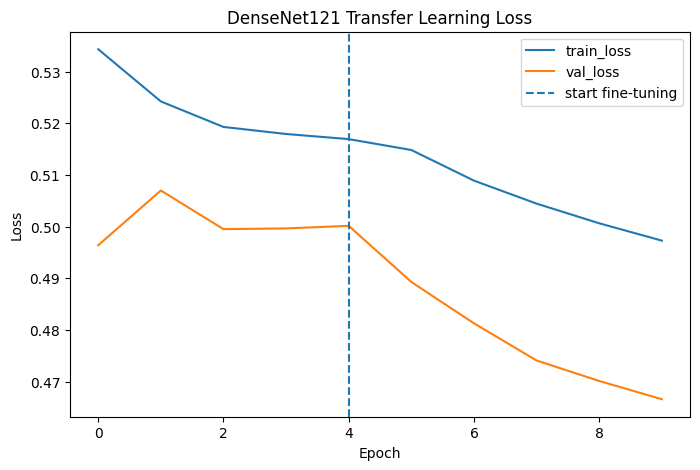

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.axvline(len(history_head_df) - 1, linestyle="--", label="start fine-tuning")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Transfer Learning Loss")
plt.legend()

plt.savefig(FIGURES_DIR / "densenet121_loss.png", dpi=300, bbox_inches="tight")
plt.show()

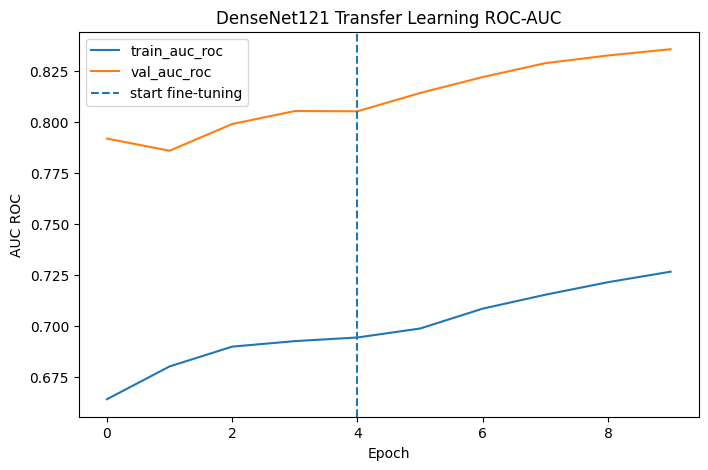

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["auc_roc"], label="train_auc_roc")
plt.plot(history_df["val_auc_roc"], label="val_auc_roc")
plt.axvline(len(history_head_df) - 1, linestyle="--", label="start fine-tuning")

plt.xlabel("Epoch")
plt.ylabel("AUC ROC")
plt.title("DenseNet121 Transfer Learning ROC-AUC")
plt.legend()

plt.savefig(FIGURES_DIR / "densenet121_auc_roc.png", dpi=300, bbox_inches="tight")
plt.show()

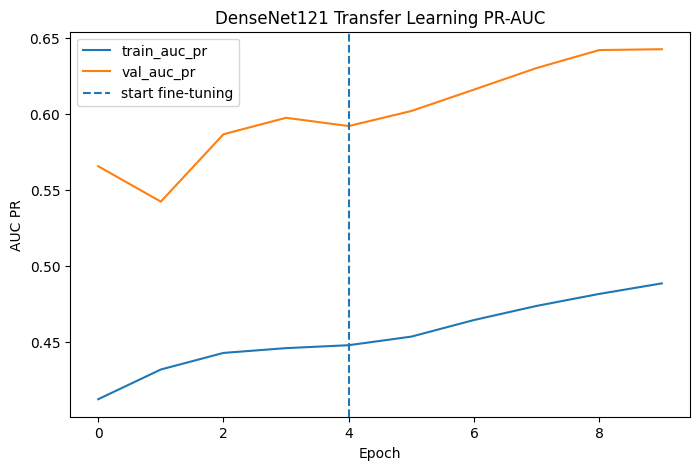

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["auc_pr"], label="train_auc_pr")
plt.plot(history_df["val_auc_pr"], label="val_auc_pr")
plt.axvline(len(history_head_df) - 1, linestyle="--", label="start fine-tuning")

plt.xlabel("Epoch")
plt.ylabel("AUC PR")
plt.title("DenseNet121 Transfer Learning PR-AUC")
plt.legend()

plt.savefig(FIGURES_DIR / "densenet121_auc_pr.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
baseline_metrics_path = RESULTS_DIR / "baseline_cnn_eval_metrics.json"
baseline_per_label_path = RESULTS_DIR / "baseline_cnn_per_label_auc.json"

with open(baseline_metrics_path, "r") as f:
    baseline_metrics = json.load(f)

with open(baseline_per_label_path, "r") as f:
    baseline_per_label = json.load(f)

comparison_df = pd.DataFrame([
    {
        "model": "baseline_cnn",
        "auc_roc": baseline_metrics.get("auc_roc"),
        "auc_pr": baseline_metrics.get("auc_pr"),
        "binary_accuracy": baseline_metrics.get("binary_accuracy"),
        "precision": baseline_metrics.get("precision"),
        "recall": baseline_metrics.get("recall"),
    },
    {
        "model": "densenet121_transfer",
        "auc_roc": eval_results.get("auc_roc"),
        "auc_pr": eval_results.get("auc_pr"),
        "binary_accuracy": eval_results.get("binary_accuracy"),
        "precision": eval_results.get("precision"),
        "recall": eval_results.get("recall"),
    }
])

comparison_path = RESULTS_DIR / "baseline_vs_densenet121_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

comparison_df

,model,auc_roc,auc_pr,binary_accuracy,precision,recall
0,baseline_cnn,0.855625,0.684061,0.780198,0.806452,0.268817
1,densenet121_transfer,0.835756,0.642677,0.762376,0.682243,0.261649


<Figure size 600x400 with 0 Axes>

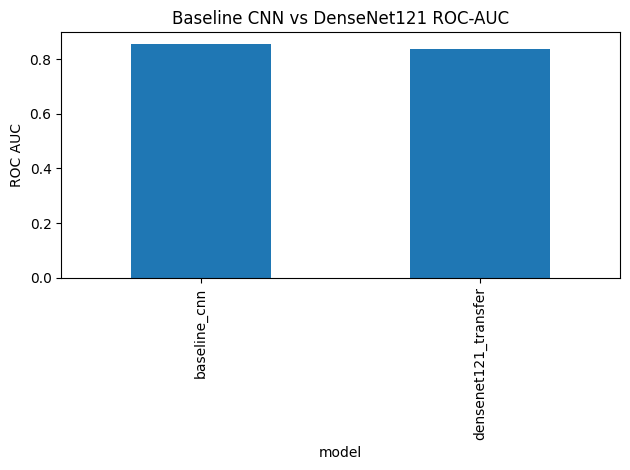

In [43]:
plt.figure(figsize=(6,4))

comparison_df.plot(
    x="model",
    y="auc_roc",
    kind="bar",
    legend=False,
    title="Baseline CNN vs DenseNet121 ROC-AUC"
)

plt.ylabel("ROC AUC")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "baseline_vs_densenet_auc.png", dpi=300)

plt.show()

In [44]:
per_label_comparison_df = pd.DataFrame({
    "label": LABELS,
    "baseline_auc": [baseline_per_label.get(label) for label in LABELS],
    "densenet121_auc": [per_label_auc.get(label) for label in LABELS],
})

per_label_comparison_df["improvement"] = (
    per_label_comparison_df["densenet121_auc"] -
    per_label_comparison_df["baseline_auc"]
)

per_label_comparison_path = RESULTS_DIR / "baseline_vs_densenet121_per_label_auc.csv"
per_label_comparison_df.to_csv(per_label_comparison_path, index=False)

per_label_comparison_df

,label,baseline_auc,densenet121_auc,improvement
0,Atelectasis,0.820367,0.801995,-0.018373
1,Cardiomegaly,0.773619,0.746769,-0.026849
2,Consolidation,0.865441,0.865257,-0.000184
3,Edema,0.928720,0.909821,-0.018899
4,Pleural Effusion,0.890851,0.854733,-0.036119


## Notebook 4 summary
- Trained DenseNet121 with ImageNet weights
- Phase 1: trained classification head with frozen backbone
- Phase 2: fine-tuned top layers of backbone
- Saved models, history, metrics, predictions, and figures
- Compared DenseNet121 against baseline CNN